In [65]:
import os
import cv2
import torch
import numpy as np
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SELECTED_MODEL = "Segformer"
SELECTED_LOSS = "Tversky"
EPOCHS = 30
PATIENCE = 5
BATCH_SIZE = 4

TRAIN_IMG_DIR = "../data/train/images"
TRAIN_MASK_DIR = "../data/train/masks"
TEST_IMG_DIR = "../data/test/images"
TEST_MASK_DIR = "../data/test/masks"

FINAL_WEIGHTS_PATH = f"production_{SELECTED_MODEL}_{SELECTED_LOSS}.pth"
VISUALS_DIR = f"production_test_visuals_{SELECTED_MODEL}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FilthDataset(Dataset):
    def __init__(self, images_dir, masks_dir, is_train=False):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.is_train = is_train
        
        self.image_names = sorted([f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.JPG'))])
        
        if self.is_train:
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.7),
                A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.7),
                A.GaussianBlur(blur_limit=(3, 7), p=0.3),
                A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.4),
                A.Resize(512, 512),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(512, 512),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.image_names)
        
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.images_dir, img_name)
            
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_path = os.path.join(self.masks_dir, img_name)
        if not os.path.exists(mask_path):
            mask_path = os.path.splitext(mask_path)[0] + '.png'
            
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path)
            mask = np.any(mask > 0, axis=-1).astype(np.float32)
        else:
            mask = np.zeros(image.shape[:2], dtype=np.float32)

        augmented = self.transform(image=image, mask=mask)
        return augmented['image'], augmented['mask'].unsqueeze(0), img_name

def get_model(model_name):
    if model_name == "DeepLabV3":
        return smp.DeepLabV3(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
    elif model_name == "UnetPlusPlus":
        return smp.UnetPlusPlus(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
    elif model_name == "Segformer":
        return smp.Segformer(encoder_name="mit_b0", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
    else:
        raise ValueError(f"Unknown model: {model_name}")

def get_loss_config(loss_name):
    if loss_name == "BCE":
        return torch.nn.BCEWithLogitsLoss(), 0.5 
    elif loss_name == "Tversky":
        return smp.losses.TverskyLoss(mode='binary', alpha=0.1, beta=0.9), 0.5
    else:
        raise ValueError(f"Unknown loss: {loss_name}")

def train_final_model(model, train_loader, val_loader, loss_fn, threshold, epochs, patience):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    print(f"\nStarting Final Production Training on {len(train_loader.dataset)} images...")
    
    best_miou = -1.0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_miou': [], 'val_miou': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_tp, train_fp, train_fn, train_tn = 0, 0, 0, 0
        
        train_bar = tqdm(train_loader, desc=f"  Epoch {epoch+1}/{epochs} [Train]", leave=True)
        
        for images, masks, _ in train_bar:
            images, masks = images.to(device), masks.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            
            with torch.no_grad():
                preds = (torch.sigmoid(outputs) > threshold).float()
                tp, fp, fn, tn = smp.metrics.get_stats(preds.long(), masks.long(), mode='binary')
                train_tp += tp.sum().item()
                train_fp += fp.sum().item()
                train_fn += fn.sum().item()
                train_tn += tn.sum().item()
            
            train_bar.set_postfix(batch_loss=f"{loss.item():.4f}")
            
        train_loss /= len(train_loader.dataset)
        train_miou = train_tp / (train_tp + train_fp + train_fn + 1e-7)
        
        model.eval()
        val_loss = 0.0
        val_tp, val_fp, val_fn, val_tn = 0, 0, 0, 0
        
        val_bar = tqdm(val_loader, desc=f"  Epoch {epoch+1}/{epochs} [Val]", leave=True)
        
        with torch.no_grad():
            for images, masks, _ in val_bar:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item() * images.size(0)
                
                preds = (torch.sigmoid(outputs) > threshold).float()
                tp, fp, fn, tn = smp.metrics.get_stats(preds.long(), masks.long(), mode='binary')
                val_tp += tp.sum().item()
                val_fp += fp.sum().item()
                val_fn += fn.sum().item()
                val_tn += tn.sum().item()
                
        val_loss /= len(val_loader.dataset)
        val_miou = val_tp / (val_tp + val_fp + val_fn + 1e-7)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_miou'].append(train_miou)
        history['val_miou'].append(val_miou)
        
        print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train mIoU: {train_miou:.4f} | Val mIoU: {val_miou:.4f}")
        
        if val_miou > best_miou:
            best_miou = val_miou
            patience_counter = 0
            torch.save(model.state_dict(), FINAL_WEIGHTS_PATH)
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"  Early stopping triggered at epoch {epoch+1}!")
            break

    if os.path.exists(FINAL_WEIGHTS_PATH):
        model.load_state_dict(torch.load(FINAL_WEIGHTS_PATH, map_location=device))

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_miou'], label='Train mIoU')
    plt.plot(history['val_miou'], label='Val mIoU')
    plt.title('Training and Validation mIoU')
    plt.xlabel('Epoch')
    plt.ylabel('mIoU')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.close()

    print(f"\nProduction model saved to: {FINAL_WEIGHTS_PATH}")
    print(f"Training curves saved to: training_curves.png")
    return model

def evaluate_and_visualize(model, test_loader, threshold):
    print(f"\nEvaluating Final Model on {len(test_loader.dataset)} locked-away test images...")
    model.eval()
    os.makedirs(VISUALS_DIR, exist_ok=True)
    
    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
    
    inv_normalize = A.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225],
        max_pixel_value=1.0
    )
    
    eval_bar = tqdm(test_loader, desc="  Generating Predictions", leave=True)
    
    with torch.no_grad():
        for images, masks, img_names in eval_bar:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > threshold).float()
            
            tp, fp, fn, tn = smp.metrics.get_stats(preds.long(), masks.long(), mode='binary')
            total_tp += tp.sum().item()
            total_fp += fp.sum().item()
            total_fn += fn.sum().item()
            total_tn += tn.sum().item()
            
            for i in range(images.size(0)):
                img_np = images[i].cpu().permute(1, 2, 0).numpy()
                img_denorm = inv_normalize(image=img_np)['image']
                img_denorm = (np.clip(img_denorm, 0, 1) * 255).astype(np.uint8)
                
                gt_mask = masks[i].cpu().squeeze().numpy()
                pred_mask = preds[i].cpu().squeeze().numpy()
                
                gt_overlay = img_denorm.copy()
                gt_overlay[gt_mask == 1] = gt_overlay[gt_mask == 1] * 0.5 + np.array([255, 0, 0]) * 0.5
                
                pred_overlay = img_denorm.copy()
                pred_overlay[pred_mask == 1] = pred_overlay[pred_mask == 1] * 0.5 + np.array([0, 0, 255]) * 0.5
                
                fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                axes[0].imshow(img_denorm)
                axes[0].set_title(f"Base Image\n({img_names[i]})")
                axes[0].axis('off')
                axes[1].imshow(gt_overlay)
                axes[1].set_title("Ground Truth (Red)")
                axes[1].axis('off')
                axes[2].imshow(pred_overlay)
                axes[2].set_title("Prediction (Blue)")
                axes[2].axis('off')
                
                plt.tight_layout()
                plt.savefig(os.path.join(VISUALS_DIR, f"eval_{img_names[i]}_result.png"))
                plt.close(fig)

    print(f"Saved {len(test_loader.dataset)} visual comparisons to '{VISUALS_DIR}/'")
    
    accuracy = (total_tp + total_tn) / (total_tp + total_fp + total_fn + total_tn + 1e-7)
    precision = total_tp / (total_tp + total_fp + 1e-7)
    recall = total_tp / (total_tp + total_fn + 1e-7)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
    iou = total_tp / (total_tp + total_fp + total_fn + 1e-7)
    
    return {
        "Accuracy": accuracy, "mIoU": iou, "Precision": precision, 
        "Recall": recall, "F1": f1,
        "TP": int(total_tp), "FP": int(total_fp), 
        "FN": int(total_fn), "TN": int(total_tn)
    }

def export_to_onnx(model, model_name, loss_name, fixed_size=(512, 512)):
    model.eval()
    model.to("cpu")
    
    onnx_filename = f"production_{model_name}_{loss_name}_512x512.onnx"
    print(f"\nExporting {model_name} to ONNX format...")
    
    dummy_input = torch.randn(1, 3, fixed_size[0], fixed_size[1], device="cpu")
    
    try:
        torch.onnx.export(
            model,
            dummy_input,
            onnx_filename,
            export_params=True,
            opset_version=12,
            do_constant_folding=True,
            input_names=['input_image'],
            output_names=['output_mask'],
            dynamic_axes={
                'input_image': {0: 'batch_size'},
                'output_mask': {0: 'batch_size'}
            }
        )
        print(f"Successfully exported ONNX model to: {onnx_filename}")
        print(f"Input shape expected: (Batch, 3, {fixed_size[0]}, {fixed_size[1]})")
    except Exception as e:
        print(f"Failed to export ONNX model. Error: {e}")
    finally:
        model.to(device)




In [66]:
print(f"Using device: {device}")

train_dataset = FilthDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, is_train=True)
test_dataset = FilthDataset(TEST_IMG_DIR, TEST_MASK_DIR, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = get_model(SELECTED_MODEL)
loss_fn, threshold = get_loss_config(SELECTED_LOSS)

model = train_final_model(model, train_loader, test_loader, loss_fn, threshold, EPOCHS, PATIENCE)

metrics = evaluate_and_visualize(model, test_loader, threshold)

print("\n" + "="*80)
print(f"FINAL PRODUCTION REPORT: {SELECTED_MODEL} ({SELECTED_LOSS} Loss)")
print("="*80)

print(f"  Pixel Accuracy: {metrics['Accuracy']:.4f}")
print(f"  mIoU:           {metrics['mIoU']:.4f}")
print(f"  Precision:      {metrics['Precision']:.4f}")
print(f"  Recall:         {metrics['Recall']:.4f}")
print(f"  F1 Score:       {metrics['F1']:.4f}")

tp, fp, fn, tn = metrics['TP'], metrics['FP'], metrics['FN'], metrics['TN']
pos_total = tp + fn + 1e-7
neg_total = fp + tn + 1e-7
tp_norm, fn_norm = (tp / pos_total) * 100, (fn / pos_total) * 100
fp_norm, tn_norm = (fp / neg_total) * 100, (tn / neg_total) * 100

print(f"\n  [Absolute Pixel Matrix]")
print(f"                   Pred Filth      Pred Clean")
print(f"    Actual Filth | TP: {tp:<10}  FN: {fn:<10}")
print(f"    Actual Clean | FP: {fp:<10}  TN: {tn:<10}")

print(f"\n  [Row-Normalized Matrix (%)]")
print(f"                   Pred Filth      Pred Clean")
print(f"    Actual Filth | TP: {tp_norm:>5.2f}%       FN: {fn_norm:>5.2f}%")
print(f"    Actual Clean | FP: {fp_norm:>5.2f}%       TN: {tn_norm:>5.2f}%")
print("="*80 + "\n")

Using device: cuda

Starting Final Production Training on 1200 images...


  Epoch 1/30 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

  Epoch 1/30 [Val]:   0%|          | 0/75 [00:00<?, ?it/s]

  Train Loss: 0.2318 | Val Loss: 0.0441 | Train mIoU: 0.2905 | Val mIoU: 0.4915


  Epoch 2/30 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

...

  Epoch 15/30 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

  Epoch 15/30 [Val]:   0%|          | 0/75 [00:00<?, ?it/s]

  Train Loss: 0.1362 | Val Loss: 0.0364 | Train mIoU: 0.5214 | Val mIoU: 0.5793
  Early stopping triggered at epoch 15!

Production model saved to: production_Segformer_Tversky.pth
Training curves saved to: training_curves.png

Evaluating Final Model on 300 locked-away test images...


  Generating Predictions:   0%|          | 0/75 [00:00<?, ?it/s]

Saved 300 visual comparisons to 'production_test_visuals_Segformer/'

FINAL PRODUCTION REPORT: Segformer (Tversky Loss)
  Pixel Accuracy: 0.9406
  mIoU:           0.5899
  Precision:      0.6096
  Recall:         0.9480
  F1 Score:       0.7421

  [Absolute Pixel Matrix]
                   Pred Filth      Pred Clean
    Actual Filth | TP: 6723855     FN: 368496    
    Actual Clean | FP: 4305815     TN: 67245034  

  [Row-Normalized Matrix (%)]
                   Pred Filth      Pred Clean
    Actual Filth | TP: 94.80%       FN:  5.20%
    Actual Clean | FP:  6.02%       TN: 93.98%



In [67]:
export_to_onnx(model, SELECTED_MODEL, SELECTED_LOSS, fixed_size=(512, 512))


Exporting Segformer to ONNX format...
Successfully exported ONNX model to: production_Segformer_Tversky_512x512.onnx
Input shape expected: (Batch, 3, 512, 512)


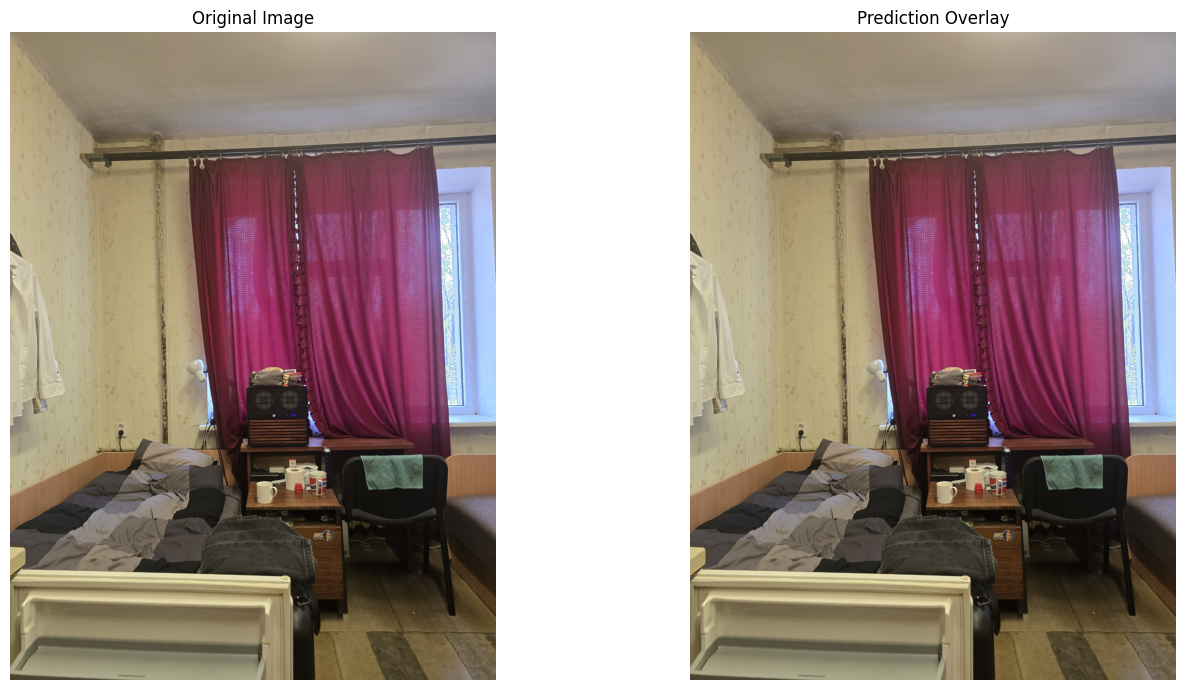

In [81]:
import os
import cv2
import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

def run_inference_on_custom_image(image_path, model_name, loss_name, threshold=0.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    weights_path = f"production_{model_name}_{loss_name}.pth"

    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Missing weights: {weights_path}")
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Missing image: {image_path}")

    model = get_model(model_name)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_height, original_width = image.shape[:2]

    transform = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    augmented = transform(image=image)
    input_tensor = augmented['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = (torch.sigmoid(output) > threshold).float().cpu().squeeze().numpy()

    pred_mask_resized = cv2.resize(pred_mask, (original_width, original_height), interpolation=cv2.INTER_NEAREST)

    overlay = image.copy()
    overlay[pred_mask_resized == 1] = overlay[pred_mask_resized == 1] * 0.5 + np.array([0, 0, 255]) * 0.5

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(overlay.astype(np.uint8))
    axes[1].set_title("Prediction Overlay")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    return pred_mask_resized

my_test_image = "../test15.jpg"

if os.path.exists(my_test_image):
    resulting_mask = run_inference_on_custom_image(
        image_path=my_test_image,
        model_name=SELECTED_MODEL,
        loss_name=SELECTED_LOSS,
        threshold=0.5
    )
else:
    print(f"File not found. Please update 'my_test_image' with a valid path.")